## RFS PreTrained SSD Fine-tuning

## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
g-drive mounted.


## 경로 설정

In [ ]:
# save_dir: 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

## 개발 환경 setup

> ### TensorFlow Model Garden을 Clone

In [ ]:
import os
import pathlib

print(pathlib.Path.cwd().parts)

# Clone the tensorflow models repository if it doesn't already exist
if "models" in pathlib.Path.cwd().parts:
  while "models" in pathlib.Path.cwd().parts:
    os.chdir('..')
elif not pathlib.Path('models').exists():
  !git clone --depth 1 https://github.com/tensorflow/models

('/', 'content')


> ### Object Detection API 설치

In [ ]:
# Install the Object Detection API
%%bash
cd models/research/
protoc object_detection/protos/*.proto --python_out=.
# cp object_detection/packages/tf2/setup.py .  # 2024.4부터 버전 문제 있음
cp /content/drive/MyDrive/files/setup.py .  # 버전 문제 패치
pip install -q .

> ### model builder 테스트

In [ ]:
# testing the model builder
!python models/research/object_detection/builders/model_builder_tf2_test.py

2025-11-29 09:29:12.284674: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-29 09:29:12.360928: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 09:29:12.361202: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 09:29:12.361298: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 09:29:12.373609: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-29 09:29:12.373948: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

> ### 모듈과 Object Detection utils 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
import io
import imageio
import glob
import scipy.misc
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Javascript
from IPython.display import Image as IPyImage

# import the object detection utils
from object_detection.utils import label_map_util
from object_detection.utils import config_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.utils import colab_utils
from object_detection.utils import config_util
from object_detection.builders import model_builder

from tensorflow.python.keras.utils.data_utils import get_file

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

/tmp/ipython-input-6-3432684251.py:9: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


NumPy Version :1.26.4
TensorFlow Version :2.14.1
Matplotlib Version :3.10.0


> ### 모델 다운로드

In [ ]:
# Download model
modelUrl = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'

filename = os.path.basename(modelUrl)
modelname = filename[:filename.index('.')]
print(filename, modelname, sep='\n')

casheDir = '.'
get_file( fname= filename,
         origin=modelUrl,
         cache_dir=casheDir,
         cache_subdir='.',
         extract=True)

ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz
ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8
20520960/20515344 [==============================] - 2s 0us/step


'././ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'

## 모델 학습 준비

> ### RPS 데이터셋 준비

In [ ]:
dataFilePath = 'RPS_Dataset_OD'

In [ ]:
# get data and unzip
dataFile = dataFilePath + '.zip'
unzipCmd = f'unzip -q -o /content/drive/MyDrive/files/{dataFile}'
!{unzipCmd}

> ### label map 만들기

In [ ]:
labelMap = os.path.relpath(f'{dataFilePath}/label_map.pbtxt')

labels = [{'name':'scissors', 'id':1},
          {'name':'rock', 'id':2},
          {'name':'paper', 'id':3}]

with open(labelMap, 'w') as f:
    for label in labels:
        f.write('item { \n')
        f.write("\tname:'{}'\n".format(label['name']))
        f.write('\tid:{}\n'.format(label['id']))
        f.write('}\n')

> ### scriptGen Clone 하기

In [ ]:
scriptGen = f'scripts/generate_tfrecord.py'
if not os.path.exists(scriptGen):
    !git clone https://github.com/nicknochnack/GenerateTFRecord scripts

Cloning into 'scripts'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


> ### record 파일 생성

In [ ]:
trainPath = os.path.relpath(f'{dataFilePath}/train')
testPath = os.path.relpath(f'{dataFilePath}/test')

In [ ]:
!python scripts/generate_tfrecord.py -x {os.path.join(dataFilePath, 'train')} -l {os.path.join(dataFilePath, 'label_map.pbtxt')} -o {os.path.join(dataFilePath, 'train.record')}
!python scripts/generate_tfrecord.py -x {os.path.join(dataFilePath, 'test')} -l {os.path.join(dataFilePath, 'label_map.pbtxt')} -o {os.path.join(dataFilePath, 'test.record')}

2025-11-29 09:30:37.105163: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 09:30:37.105565: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 09:30:37.105733: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Successfully created the TFRecord file: RPS_Dataset_OD/train.record
2025-11-29 09:30:43.118512: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 09:30:43.118698: E tensorflow/compiler/xla/stream_executor/cuda/cuda_ff

> ### pipline 설정

In [ ]:
!mkdir checkpoint
!cp /content/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config checkpoint

In [ ]:
from google.protobuf import text_format
from object_detection.protos import pipeline_pb2

In [ ]:
pipeConfigFile = 'checkpoint/pipeline.config'

In [ ]:
pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(pipeConfigFile, "r") as f:
    proto_str = f.read()
    text_format.Merge(proto_str, pipeline_config)

In [ ]:
pipeline_config.model.ssd.num_classes = len(labels)
pipeline_config.train_config.batch_size = 5
pipeline_config.train_config.fine_tune_checkpoint = f'{modelname}/checkpoint/ckpt-0'
pipeline_config.train_config.fine_tune_checkpoint_type = "detection"
pipeline_config.train_input_reader.label_map_path= labelMap
pipeline_config.train_input_reader.tf_record_input_reader.input_path[0] = f'{dataFilePath}/train.record'
# pipeline_config.eval_config.max_evals = 1
pipeline_config.eval_input_reader[0].label_map_path = labelMap
pipeline_config.eval_input_reader[0].tf_record_input_reader.input_path[0] = f'{dataFilePath}/test.record'

In [ ]:
config_text = text_format.MessageToString(pipeline_config)
with tf.io.gfile.GFile(pipeConfigFile, "wb") as f:
    f.write(config_text)

## 모델 학습

In [ ]:
trainScript = '/content/models/research/object_detection/model_main_tf2.py'

In [ ]:
trainCmd = 'python {} --model_dir={} --pipeline_config_path={} --num_train_steps=2000'.format(
                 trainScript, 'checkpoint', pipeConfigFile )

In [ ]:
# 버전 문제 패치
!cp -f /content/drive/MyDrive/files/tfexample_decoder.py /usr/local/lib/python3.11/dist-packages/tf_slim/data/tfexample_decoder.py

In [ ]:
!{trainCmd}

2025-11-29 09:33:37.802603: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 09:33:37.802780: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 09:33:37.803019: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 09:33:39.854580: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-11-29 09:33:43.795096: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the 

## 테스트를 위한 모듈 로딩

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
import time

## 테스트를 위한 detection 함수

In [ ]:
# Load pipeline config and build a detection model
configs = config_util.get_configs_from_pipeline_file(pipeConfigFile)
detection_model = model_builder.build(model_config=configs['model'], is_training=False)
# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
ckpt.restore('checkpoint/ckpt-3').expect_partial()

@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections

## 이미지 테스트

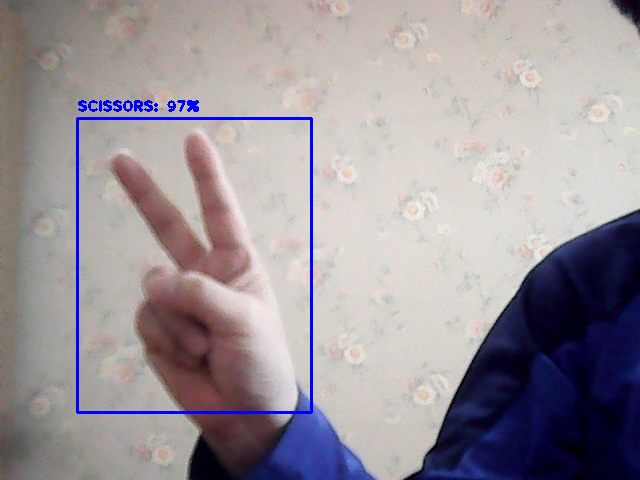

In [ ]:
classList = '_ Scissors Rock Paper'.split()
colorList = [(), (255, 0, 0), (0, 255, 0), (0, 0, 255)]
IMG_SIZE = 320
threshold = 0.8

def createBB(frame):
  # frame 크기 저장 -> BB 표시할 때 사용
  frameH, frameW, _ = frame.shape

  # BGR을 RGB로 변경
  img = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

  # 모델의 입력 형태로 수정: (1,320,320,3)
  img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
  img = np.expand_dims(img, 0)
  input_tensor = tf.convert_to_tensor(img, dtype=tf.float32)

  # 모델에 입력하여 결과 얻기
  detections = detect_fn(input_tensor)
  bboxes = detections['detection_boxes'][0].numpy()
  classIndexes = detections['detection_classes'][0].numpy().astype(np.int32)
  classScores = detections['detection_scores'][0].numpy()

  for bbox, c, cs in zip( bboxes, classIndexes, classScores):
      # score가 threshold 이하이면 skip
      if cs <= threshold: continue

      # score를 100 분율로 환산
      classConfidence = round(cs*100 )

      # BB 표시
      classIndex = c + 1 # shift 필요: 0 1 2 -> 1 2 3
      classLabel = classList[classIndex]
      classColor = colorList[classIndex]
      displayText = f'{classLabel}: {classConfidence}%'.upper()
      ymin, xmin, ymax, xmax = bbox
      xmin, xmax, ymin, ymax = int(xmin*frameW), int(xmax*frameW), int(ymin*frameH), int(ymax*frameH)
      cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color=classColor, thickness=2)
      cv2.putText(frame, displayText, (xmin, ymin-7),
                  cv2.FONT_HERSHEY_PLAIN, fontScale=1, color=classColor, thickness=2)

test_img = '/content/drive/MyDrive/files/images/img_0001.jpg'
frame = cv2.imread(test_img)
createBB(frame)
cv2_imshow(frame)

## Java script and functions for Video streaming on colab

In [ ]:
from base64 import b64decode, b64encode
import PIL

In [ ]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [ ]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;
    const img_w = 640;
    const img_h = 480;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, img_w, img_h); // , 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = img_w; // 640; //video.videoWidth;
      captureCanvas.height = img_h; //480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

## 이미지 처리

In [ ]:
classList = '_ Scissors Rock Paper'.split()
colorList = [(), (0, 0, 255), (0, 255, 0), (255, 0, 0)]
IMG_SIZE = 320
threshold = 0.8

def processImage(js_reply, fps):
  # webcam 이미지를 포함하고 있는 JavaScript object(js_reply)를 OpenCV 이미지로 변환
  frame = js_to_image(js_reply["img"])

  # frame 크기 저장 -> BB 표시할 때 사용
  frameH, frameW, _ = frame.shape

  # BGR을 RGB로 변경
  img = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

  # 모델의 입력 형태로 수정: (1,320,320,3)
  img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
  img = np.expand_dims(img, 0)
  input_tensor = tf.convert_to_tensor(img, dtype=tf.float32)

  # 모델에 입력하여 결과 얻기
  detections = detect_fn(input_tensor)
  bboxes = detections['detection_boxes'][0].numpy()
  classIndexes = detections['detection_classes'][0].numpy().astype(np.int32)
  classScores = detections['detection_scores'][0].numpy()

  # 투명도를 가진 bounding box용 ndarray(bbox_array) 생성
  bbox_array = np.zeros([frameH,frameW,4], dtype=np.uint8)

  for bbox, c, cs in zip( bboxes, classIndexes, classScores):
      # score가 threshold 이하이면 skip
      if cs <= threshold: continue

      # score를 100 분율로 환산
      classConfidence = round(cs*100 )

      # bbox_array에 BB 표시
      classIndex = c + 1 # shift 필요: 0 1 2 -> 1 2 3
      classLabel = classList[classIndex]
      classColor = colorList[classIndex]
      displayText = f'{classLabel}: {classConfidence}%'.upper()
      ymin, xmin, ymax, xmax = bbox
      xmin, xmax, ymin, ymax = int(xmin*frameW), int(xmax*frameW), int(ymin*frameH), int(ymax*frameH)
      cv2.rectangle(bbox_array, (xmin, ymin), (xmax, ymax), color=classColor, thickness=2)
      cv2.putText(bbox_array, displayText, (xmin, ymin-7),
                  cv2.FONT_HERSHEY_PLAIN, fontScale=1, color=classColor, thickness=2)

  # bbox_array에 FPS 표시
  cv2.putText(bbox_array,f'FPS:{fps:.1f}',(50,50),cv2.FONT_ITALIC,1,(255, 255, 0),2)

  # bbox_array에서 bounding box와 fps가 표시된 부분을 불투명 처리
  bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ) * 255

  # bbox_array를 base64 byte string(bbox)로 변경
  bbox = bbox_to_bytes(bbox_array)

  # bbox를 리턴
  return bbox

## 카메라 테스트

In [ ]:
# webcam video stream 시작
video_stream()
# video 출력창에 표시되는 label 설정
label_html = 'Capturing...'
# 비어있는 상태로 bbox 초기화
bbox = ''

startTime = time.time()
while True:
  # video 출력창에 bbox를 추가하고 현재 frame을 리턴
  js_reply = video_frame(label_html, bbox)
  if not js_reply: break

  # FPS 계산
  curTime = time.time()
  fps = 1/(curTime - startTime)
  startTime = curTime

  # 이미지 처리
  bbox = processImage(js_reply, fps)

<IPython.core.display.Javascript object>

## 모델 저장

In [ ]:
savedModel = 'RPS_PreTrained_SSD'

In [ ]:
savescript = '/content/models/research/object_detection/exporter_main_v2.py'
saveCmd = 'python {} --input_type=image_tensor --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}'.format(
            savescript, pipeConfigFile, 'checkpoint', savedModel
)

In [ ]:
!{saveCmd}

2025-11-29 10:35:21.746263: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 10:35:21.746459: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 10:35:21.746590: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 10:35:23.111463: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-11-29 10:35:27.791981: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the 

In [ ]:
zipCmd = f'zip -r {savedModel}.zip {savedModel}'
!{zipCmd}

  adding: RPS_PreTrained_SSD/ (stored 0%)
  adding: RPS_PreTrained_SSD/pipeline.config (deflated 68%)
  adding: RPS_PreTrained_SSD/saved_model/ (stored 0%)
  adding: RPS_PreTrained_SSD/saved_model/assets/ (stored 0%)
  adding: RPS_PreTrained_SSD/saved_model/variables/ (stored 0%)
  adding: RPS_PreTrained_SSD/saved_model/variables/variables.data-00000-of-00001 (deflated 9%)
  adding: RPS_PreTrained_SSD/saved_model/variables/variables.index (deflated 78%)
  adding: RPS_PreTrained_SSD/saved_model/saved_model.pb (deflated 92%)
  adding: RPS_PreTrained_SSD/saved_model/fingerprint.pb (stored 0%)
  adding: RPS_PreTrained_SSD/checkpoint/ (stored 0%)
  adding: RPS_PreTrained_SSD/checkpoint/ckpt-0.data-00000-of-00001 (deflated 8%)
  adding: RPS_PreTrained_SSD/checkpoint/checkpoint (deflated 40%)
  adding: RPS_PreTrained_SSD/checkpoint/ckpt-0.index (deflated 80%)


In [ ]:
cpCmd = f'cp {savedModel}.zip {save_dir}'
print(cpCmd)
!{cpCmd}

cp RPS_PreTrained_SSD.zip /content/drive/MyDrive/files/save/


## LiteRT로 변환

In [ ]:
tfliteScript = '/content/models/research/object_detection/export_tflite_graph_tf2.py'
tfliteCmd = 'python {} --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}'.format(
            tfliteScript,  pipeConfigFile, 'checkpoint', 'tflite_model'
)

In [ ]:
!{tfliteCmd}

2025-11-29 10:36:39.768836: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 10:36:39.769273: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 10:36:39.769393: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 10:36:41.338788: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-11-29 10:36:44.730874: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the 

In [ ]:
tfliteFile = 'RPS_PreTrained_SSD.tflite'
tflitePath = 'tflite_model/saved_model'
tfliteModel = 'tflite_model/' + tfliteFile
command = "tflite_convert \
--saved_model_dir={} \
--output_file={} \
--input_shapes=1,300,300,3 \
--input_arrays=normalized_input_image_tensor \
--output_arrays='TFLite_Detection_PostProcess','TFLite_Detection_PostProcess:1','TFLite_Detection_PostProcess:2','TFLite_Detection_PostProcess:3' \
--inference_type=FLOAT \
--allow_custom_ops".format(tflitePath, tfliteModel )

In [ ]:
!{command}

2025-11-29 10:37:41.849147: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 10:37:41.849324: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 10:37:41.849415: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 10:37:43.288841: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-11-29 10:37:45.951455: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the 

In [ ]:
cpCmd = f'cp {tfliteModel} {save_dir}'
print(cpCmd)
!{cpCmd}

cp tflite_model/RPS_PreTrained_SSD.tflite /content/drive/MyDrive/files/save/
